# ResNet50 KeFRA Paper Replica Notebook

This notebook recreates the experimental setup from:

**Abu Al-Haija & Alsulami (2022), _Detection of Fake Replay Attack Signals on Remote Keyless Controlled Vehicles Using Pre-Trained Deep Neural Network_, Electronics 11(20), 3376.**

The paper setup being replicated:

- Dataset: **KeFRA Images: Key-fob RKE Replay Attack**
- Classes: `Real_Signal`, `Fake_Signal_High_Gain`, `Fake_Signal_Low_Gain`
- Original image size: approximately `1288 x 421 x 3`
- ResNet50 input size: `224 x 224 x 3`
- Transfer learning model: ImageNet-pretrained ResNet50
- Frozen feature extractor, replaced final classification layer for 3 classes
- Optimizers/solvers: SGD, Adam, RMSProp
- Learning rate: `0.001`
- Epochs: `100`
- Mini-batch size: `8`
- Train/test distribution: `90% / 10%`
- 5-fold cross-validation
- Metrics: NCC, NIC, ACC, PRC, RCL, F1S, INF

## Important setup notes

1. **You must use the image dataset, not the CSV-converted waveform dataset.**  
   Put the downloaded/unzipped KeFRA image dataset somewhere like:

   ```text
   data/Kefra/
       Real_Signal/
       Fake_Signal_High_Gain/
       Fake_Signal_Low_Gain/
   ```

2. **Image resizing is handled inside this notebook.**  
   You do not need to resize images manually. The notebook resizes every image to `224 x 224` before feeding it to ResNet50.

3. **ResNet50 weights are downloaded automatically by torchvision the first time you run the notebook.**  
   This requires internet access once. After that, PyTorch caches the weights locally.

4. **Leakage warning:** the paper text describes augmentation before shuffling/splitting. That can place augmented versions of the same original image in both training and testing. This notebook defaults to a leakage-safe mode: split originals first, augment training only, and test on untouched originals. To mimic the paper-described flow more closely, set `SPLIT_MODE = "paper_described"` in Block 1.

5. **Exact numeric reproduction is not guaranteed.** The paper was implemented in MATLAB R2021b on different hardware. This notebook is a faithful PyTorch reproduction of the stated architecture, preprocessing, optimizers, and metrics.

In [3]:
# ============================================================
# Block 0: Install/check dependencies
# ============================================================
# Uncomment if needed:
# !pip install torch torchvision scikit-learn pandas numpy matplotlib seaborn pillow tqdm

import os
import time
import random
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models
from torchvision.models import ResNet50_Weights
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


## Block 1: Dataset configuration

Set `DATA_ROOT` to the folder containing the three KeFRA class folders. The class folder names below match the names used in your previous scripts and the dataset description.

`SPLIT_MODE` options:

- `"leakage_safe"`: split original images first, augment training only, test on untouched originals. Recommended.
- `"paper_described"`: augment all images first, then random split. Closer to the paper text, but can leak related augmented images across train/test.

In [4]:
# ============================================================
# Block 1: Dataset paths and experimental constants
# ============================================================

DATA_ROOT = Path("data/Kefra")  # <-- change this if your dataset is elsewhere

CLASS_FOLDERS = {
    "Real": "Real_Signal",
    "Fake_High": "Fake_Signal_High_Gain",
    "Fake_Low": "Fake_Signal_Low_Gain",
}

CLASS_NAMES = list(CLASS_FOLDERS.keys())
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}

# Recommended: leakage_safe. Use paper_described only if you intentionally want to mirror the paper text.
SPLIT_MODE = "paper_described"  # "leakage_safe" or "paper_described"

IMAGE_SIZE = 224
BATCH_SIZE = 4
LEARNING_RATE = 1e-3
NUM_EPOCHS = 100
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

# Paper-style augmentation count: 6 transformations per original image.
AUGMENTATION_NAMES = [
    "x_reflection",
    "y_reflection",
    "rotation",
    "rescaling",
    "horizontal_translation",
    "vertical_translation",
]

# Augmentation hyperparameters. The paper says random min/max but does not publish exact values.
ROTATION_DEGREES = 10
SCALE_RANGE = (0.90, 1.10)
TRANSLATE_FRAC = 0.10

print("DATA_ROOT:", DATA_ROOT.resolve())
print("SPLIT_MODE:", SPLIT_MODE)
print("Classes:", CLASS_NAMES)

DATA_ROOT: /home/ronan/poly/rfid/Anomalous-RFID-Detection/data/Kefra
SPLIT_MODE: paper_described
Classes: ['Real', 'Fake_High', 'Fake_Low']


In [5]:
# ============================================================
# Block 2: Find images and verify class counts
# ============================================================

VALID_EXTS = {".bmp", ".png", ".jpg", ".jpeg", ".tif", ".tiff"}

def collect_image_records(data_root: Path):
    records = []
    for class_name, folder_name in CLASS_FOLDERS.items():
        folder = data_root / folder_name
        if not folder.exists():
            raise FileNotFoundError(
                f"Missing folder: {folder}\n"
                f"Expected structure: {data_root}/Real_Signal, "
                f"Fake_Signal_High_Gain, Fake_Signal_Low_Gain"
            )
        paths = sorted([p for p in folder.rglob("*") if p.suffix.lower() in VALID_EXTS])
        for p in paths:
            records.append({
                "path": str(p),
                "class_name": class_name,
                "label": CLASS_TO_IDX[class_name],
                "source_id": p.stem,
            })
    return pd.DataFrame(records)

records_df = collect_image_records(DATA_ROOT)
print("Total original images:", len(records_df))
display(records_df.groupby("class_name").size().reindex(CLASS_NAMES))

if len(records_df) == 0:
    raise RuntimeError("No images found. Check DATA_ROOT and class folders.")

# The paper reports 110 real, 110 fake high, 120 fake low = 340 total.
expected_counts = {"Real": 110, "Fake_High": 110, "Fake_Low": 120}
actual_counts = records_df.groupby("class_name").size().to_dict()
print("Expected paper counts:", expected_counts)
print("Actual counts:", actual_counts)
if actual_counts != expected_counts:
    print("WARNING: Your local dataset counts differ from the counts reported in the paper.")

Total original images: 340


class_name
Real         110
Fake_High    110
Fake_Low     120
dtype: int64

Expected paper counts: {'Real': 110, 'Fake_High': 110, 'Fake_Low': 120}
Actual counts: {'Fake_High': 110, 'Fake_Low': 120, 'Real': 110}


## Block 3: Datasets and exact six paper-style augmentations

The paper lists six image transformations:

1. Random reflection axis X
2. Random reflection axis Y
3. Random image rotation
4. Random image rescaling
5. Random horizontal translation
6. Random vertical translation

This implementation creates exactly one deterministic version of each transformation per source image, giving a 6x expansion factor just like the paper's `340 -> 2040` statement.

In [6]:
# ============================================================
# Block 3: Dataset classes and transforms
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def pil_to_resnet_tensor(img: Image.Image):
    img = img.convert("RGB")
    img = TF.resize(img, [IMAGE_SIZE, IMAGE_SIZE], interpolation=InterpolationMode.BILINEAR)
    x = TF.to_tensor(img)
    x = TF.normalize(x, IMAGENET_MEAN, IMAGENET_STD)
    return x


def deterministic_uniform(seed_value, low, high):
    seed_value = int(seed_value)
    rng = random.Random(seed_value)
    return rng.uniform(low, high)

def apply_paper_augmentation(img: Image.Image, aug_id: int, seed_value: int):
    """Apply one of the six transformations described in the paper."""
    img = img.convert("RGB")

    if aug_id == 0:
        # X-axis reflection in image terms: horizontal flip.
        return TF.hflip(img)

    if aug_id == 1:
        # Y-axis reflection in image terms: vertical flip.
        return TF.vflip(img)

    if aug_id == 2:
        angle = deterministic_uniform(seed_value + 1000, -ROTATION_DEGREES, ROTATION_DEGREES)
        return TF.rotate(img, angle=angle, interpolation=InterpolationMode.BILINEAR, fill=255)

    if aug_id == 3:
        scale = deterministic_uniform(seed_value + 2000, SCALE_RANGE[0], SCALE_RANGE[1])
        return TF.affine(
            img,
            angle=0,
            translate=[0, 0],
            scale=scale,
            shear=[0.0, 0.0],
            interpolation=InterpolationMode.BILINEAR,
            fill=255,
        )

    if aug_id == 4:
        w, h = img.size
        max_dx = int(TRANSLATE_FRAC * w)
        dx = int(deterministic_uniform(seed_value + 3000, -max_dx, max_dx))
        return TF.affine(
            img,
            angle=0,
            translate=[dx, 0],
            scale=1.0,
            shear=[0.0, 0.0],
            interpolation=InterpolationMode.BILINEAR,
            fill=255,
        )

    if aug_id == 5:
        w, h = img.size
        max_dy = int(TRANSLATE_FRAC * h)
        dy = int(deterministic_uniform(seed_value + 4000, -max_dy, max_dy))
        return TF.affine(
            img,
            angle=0,
            translate=[0, dy],
            scale=1.0,
            shear=[0.0, 0.0],
            interpolation=InterpolationMode.BILINEAR,
            fill=255,
        )

    raise ValueError(f"Invalid aug_id: {aug_id}")


class OriginalImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True).copy()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        x = pil_to_resnet_tensor(img)
        y = int(row["label"])
        return x, y


class SixAugmentedImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, augmented_indices=None):
        self.df = df.reset_index(drop=True).copy()
        self.n_aug = len(AUGMENTATION_NAMES)
        if augmented_indices is None:
            self.augmented_indices = list(range(len(self.df) * self.n_aug))
        else:
            self.augmented_indices = list(augmented_indices)

    def __len__(self):
        return len(self.augmented_indices)

    def __getitem__(self, idx):
        global_aug_idx = self.augmented_indices[idx]
        base_idx = global_aug_idx // self.n_aug
        aug_id = global_aug_idx % self.n_aug
        row = self.df.iloc[base_idx]
        img = Image.open(row["path"]).convert("RGB")
        img = apply_paper_augmentation(img, aug_id=aug_id, seed_value=SEED + global_aug_idx)
        x = pil_to_resnet_tensor(img)
        y = int(row["label"])
        return x, y


def make_loader(dataset, shuffle=False):
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

print("Dataset classes ready.")

Dataset classes ready.


In [7]:
# ============================================================
# Block 4: Train/test split
# ============================================================

labels_original = records_df["label"].to_numpy()

if SPLIT_MODE == "leakage_safe":
    train_df, test_df = train_test_split(
        records_df,
        test_size=0.10,
        random_state=SEED,
        shuffle=True,
        stratify=labels_original,
    )
    train_dataset = SixAugmentedImageDataset(train_df)
    test_dataset = OriginalImageDataset(test_df)

    print("Leakage-safe mode")
    print("Original train images:", len(train_df))
    print("Augmented train images:", len(train_dataset))
    print("Untouched test images:", len(test_df))

elif SPLIT_MODE == "paper_described":
    full_aug_dataset = SixAugmentedImageDataset(records_df)
    y_aug = np.repeat(records_df["label"].to_numpy(), len(AUGMENTATION_NAMES))
    all_aug_indices = np.arange(len(full_aug_dataset))

    aug_train_idx, aug_test_idx = train_test_split(
        all_aug_indices,
        test_size=0.10,
        random_state=SEED,
        shuffle=True,
        stratify=y_aug,
    )
    train_dataset = SixAugmentedImageDataset(records_df, augmented_indices=aug_train_idx)
    test_dataset = SixAugmentedImageDataset(records_df, augmented_indices=aug_test_idx)

    print("Paper-described mode: augmentation before split")
    print("WARNING: This can leak augmented siblings across train/test.")
    print("Augmented train images:", len(train_dataset))
    print("Augmented test images:", len(test_dataset))

else:
    raise ValueError("SPLIT_MODE must be 'leakage_safe' or 'paper_described'")

train_loader = make_loader(train_dataset, shuffle=True)
test_loader = make_loader(test_dataset, shuffle=False)

# Quick label count helper

def dataset_label_counts(dataset):
    counts = Counter()
    for _, y in DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0):
        counts.update(y.numpy().tolist())
    return {IDX_TO_CLASS[k]: v for k, v in sorted(counts.items())}

print("Train counts:", dataset_label_counts(train_dataset))
print("Test counts:", dataset_label_counts(test_dataset))

Paper-described mode: augmentation before split
Augmented train images: 1836
Augmented test images: 204
Train counts: {'Real': 594, 'Fake_High': 594, 'Fake_Low': 648}
Test counts: {'Real': 66, 'Fake_High': 66, 'Fake_Low': 72}


## Block 5: Build the pre-trained ResNet50 transfer-learning model

The feature extractor is ImageNet-pretrained ResNet50. All pre-trained layers are frozen, and the final fully connected layer is replaced with a 3-class classifier.

In [8]:
# ============================================================
# Block 5: ResNet50 model and optimizer factory
# ============================================================

def build_resnet50_transfer_model(num_classes=3, freeze_backbone=True):
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = models.resnet50(weights=weights)

    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model.to(DEVICE)


def make_optimizer(name, model):
    params = [p for p in model.parameters() if p.requires_grad]
    lname = name.lower()
    if lname == "sgd":
        # MATLAB's common SGD solver is SGDM. Momentum is set explicitly here.
        return torch.optim.SGD(params, lr=LEARNING_RATE, momentum=0.9)
    if lname == "adam":
        return torch.optim.Adam(params, lr=LEARNING_RATE)
    if lname == "rmsprop":
        return torch.optim.RMSprop(params, lr=LEARNING_RATE)
    raise ValueError(f"Unknown optimizer: {name}")

OPTIMIZERS_TO_TEST = ["SGD", "Adam", "RMSProp"]

# Build once to force/check ResNet50 weight download.
_tmp_model = build_resnet50_transfer_model()
print("ResNet50 transfer model ready. Final layer:", _tmp_model.fc)
del _tmp_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

ResNet50 transfer model ready. Final layer: Linear(in_features=2048, out_features=3, bias=True)


In [9]:
# ============================================================
# Block 6: Training and evaluation functions
# ============================================================

def train_one_model(model, train_loader, optimizer_name, num_epochs=NUM_EPOCHS):
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(optimizer_name, model)

    history = []
    model.train()

    for epoch in range(1, num_epochs + 1):
        running_loss = 0.0
        running_correct = 0
        running_total = 0

        pbar = tqdm(train_loader, desc=f"{optimizer_name} epoch {epoch}/{num_epochs}", leave=False)
        for x, y in pbar:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            batch_size = y.size(0)
            running_loss += loss.item() * batch_size
            preds = logits.argmax(dim=1)
            running_correct += (preds == y).sum().item()
            running_total += batch_size
            pbar.set_postfix(loss=running_loss / running_total, acc=running_correct / running_total)

        history.append({
            "epoch": epoch,
            "train_loss": running_loss / running_total,
            "train_accuracy": running_correct / running_total,
        })

    return pd.DataFrame(history)


@torch.no_grad()
def predict_model(model, loader):
    model.eval()
    all_probs = []
    all_preds = []
    all_true = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    start = time.perf_counter()

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_true.append(y.numpy())

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    end = time.perf_counter()

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_preds)
    y_prob = np.vstack(all_probs)
    inf_total_sec = end - start
    inf_per_sample_sec = inf_total_sec / len(y_true)
    return y_true, y_pred, y_prob, inf_total_sec, inf_per_sample_sec


def paper_style_metrics(y_true, y_pred, inf_total_sec, inf_per_sample_sec):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
    ncc = int(np.trace(cm))
    nic = int(cm.sum() - ncc)
    return {
        "NCC": ncc,
        "NIC": nic,
        "ACC": accuracy_score(y_true, y_pred),
        "PRC": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "RCL": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1S": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "PRC_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "RCL_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1S_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "INF_total_sec": inf_total_sec,
        "INF_per_sample_sec": inf_per_sample_sec,
    }, cm

print("Training/evaluation functions ready.")

Training/evaluation functions ready.


## Block 7: Train SGD, Adam, and RMSProp on the 90/10 split

This is the main paper-style comparison. It trains three separate ResNet50 transfer-learning models and records the seven indicators used in the paper.

In [10]:
# ============================================================
# Block 7: Main 90/10 optimizer comparison
# ============================================================

trained_runs = {}
metric_rows = []
confusion_matrices = {}

for optimizer_name in OPTIMIZERS_TO_TEST:
    print("\n" + "=" * 70)
    print(f"Training ResNet50 with optimizer: {optimizer_name}")
    print("=" * 70)

    model = build_resnet50_transfer_model(num_classes=len(CLASS_NAMES), freeze_backbone=True)
    history_df = train_one_model(model, train_loader, optimizer_name, num_epochs=NUM_EPOCHS)

    y_true, y_pred, y_prob, inf_total_sec, inf_per_sample_sec = predict_model(model, test_loader)
    metrics, cm = paper_style_metrics(y_true, y_pred, inf_total_sec, inf_per_sample_sec)

    row = {"optimizer": optimizer_name, **metrics}
    metric_rows.append(row)
    confusion_matrices[optimizer_name] = cm
    trained_runs[optimizer_name] = {
        "model": model,
        "history": history_df,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix": cm,
        "metrics": row,
    }

    print("Metrics:")
    display(pd.DataFrame([row]))
    print("Classification report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

results_df = pd.DataFrame(metric_rows).sort_values(["ACC", "F1S"], ascending=False).reset_index(drop=True)
print("\nPaper-style Table 2 replica:")
display(results_df)
results_df.to_csv("paper_style_table2_optimizer_metrics.csv", index=False)
print("Saved: paper_style_table2_optimizer_metrics.csv")


Training ResNet50 with optimizer: SGD


SGD epoch 1/100:   0%|          | 0/459 [00:00<?, ?it/s]

SGD epoch 2/100:   0%|          | 0/459 [00:00<?, ?it/s]

SGD epoch 3/100:   0%|          | 0/459 [00:00<?, ?it/s]

SGD epoch 4/100:   0%|          | 0/459 [00:00<?, ?it/s]

...

Metrics:


,optimizer,NCC,NIC,ACC,PRC,RCL,F1S,PRC_macro,RCL_macro,F1S_macro,INF_total_sec,INF_per_sample_sec
0,RMSProp,142,62,0.696078,0.699314,0.696078,0.695793,0.701789,0.699495,0.698696,2.10954,0.010341


Classification report:
              precision    recall  f1-score   support

        Real       0.82      0.74      0.78        66
   Fake_High       0.67      0.77      0.72        66
    Fake_Low       0.62      0.58      0.60        72

    accuracy                           0.70       204
   macro avg       0.70      0.70      0.70       204
weighted avg       0.70      0.70      0.70       204


Paper-style Table 2 replica:


,optimizer,NCC,NIC,ACC,PRC,RCL,F1S,PRC_macro,RCL_macro,F1S_macro,INF_total_sec,INF_per_sample_sec
0,RMSProp,142,62,0.696078,0.699314,0.696078,0.695793,0.701789,0.699495,0.698696,2.109540,0.010341
1,Adam,142,62,0.696078,0.692162,0.696078,0.689264,0.693115,0.701599,0.692632,2.190348,0.010737
2,SGD,139,65,0.681373,0.677276,0.681373,0.671653,0.677986,0.687710,0.675388,2.110433,0.010345


Saved: paper_style_table2_optimizer_metrics.csv



Confusion matrix: SGD


,Predicted Real,Predicted Fake_High,Predicted Fake_Low
Actual Real,56,5,5
Actual Fake_High,4,49,13
Actual Fake_Low,18,20,34


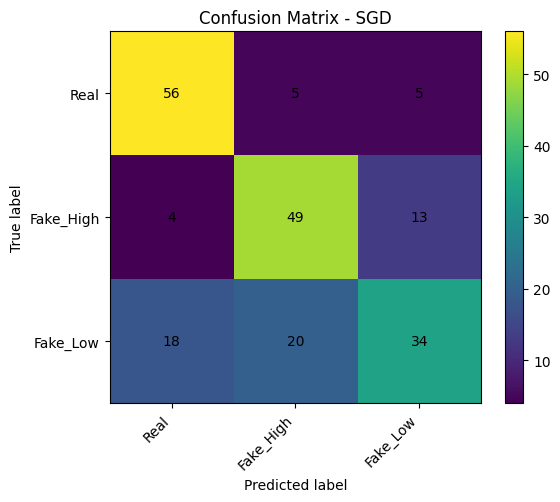


Confusion matrix: Adam


,Predicted Real,Predicted Fake_High,Predicted Fake_Low
Actual Real,54,4,8
Actual Fake_High,4,51,11
Actual Fake_Low,17,18,37


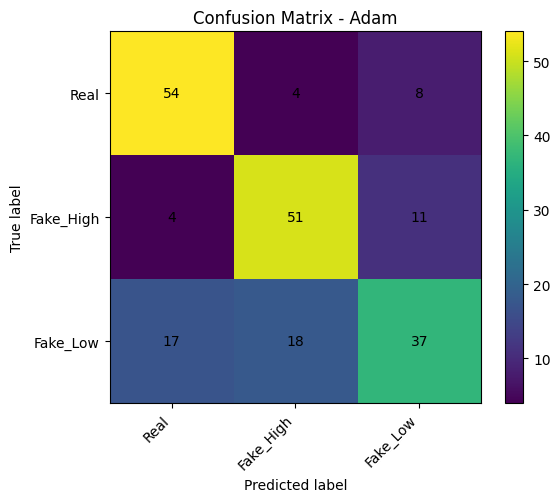


Confusion matrix: RMSProp


,Predicted Real,Predicted Fake_High,Predicted Fake_Low
Actual Real,49,5,12
Actual Fake_High,1,51,14
Actual Fake_Low,10,20,42


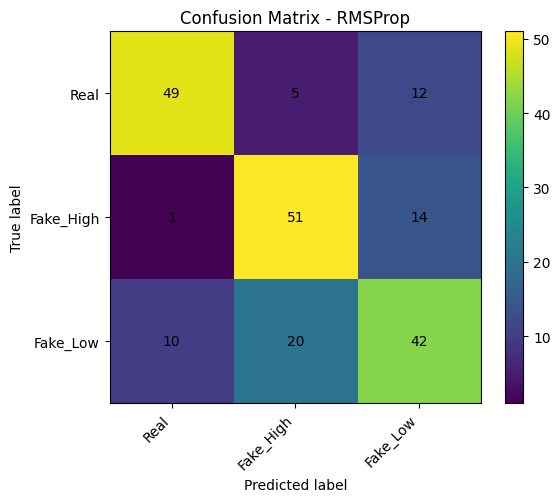

In [11]:
# ============================================================
# Block 8: Figure 7 replica - confusion matrices for all optimizers
# ============================================================

for optimizer_name in OPTIMIZERS_TO_TEST:
    cm = confusion_matrices[optimizer_name]
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {c}" for c in CLASS_NAMES],
        columns=[f"Predicted {c}" for c in CLASS_NAMES],
    )
    print(f"\nConfusion matrix: {optimizer_name}")
    display(cm_df)
    cm_df.to_csv(f"confusion_matrix_{optimizer_name}.csv")

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {optimizer_name}")
    plt.colorbar()
    tick_marks = np.arange(len(CLASS_NAMES))
    plt.xticks(tick_marks, CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(tick_marks, CLASS_NAMES)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(f"figure7_confusion_matrix_{optimizer_name}.png", dpi=200, bbox_inches="tight")
    plt.show()

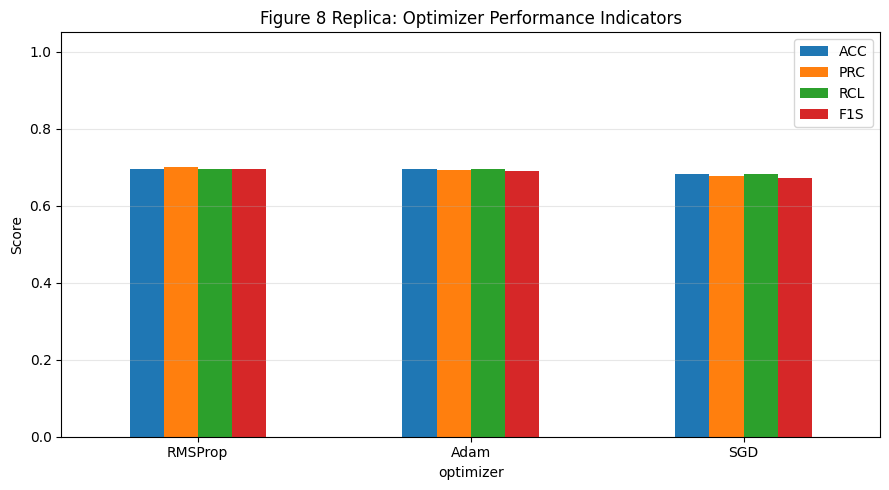

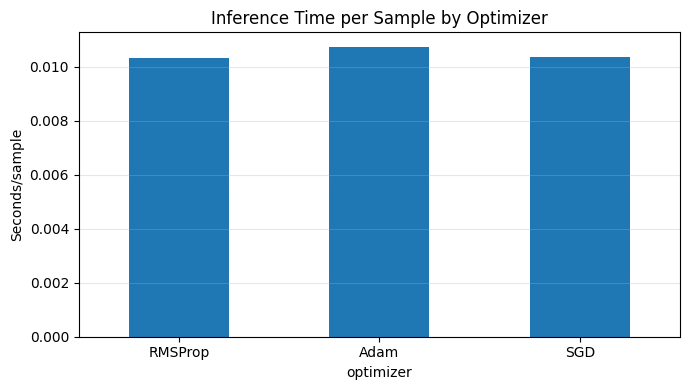

In [12]:
# ============================================================
# Block 9: Figure 8 replica - performance indicator comparison
# ============================================================

plot_metrics = ["ACC", "PRC", "RCL", "F1S"]
plot_df = results_df.set_index("optimizer")[plot_metrics]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Figure 8 Replica: Optimizer Performance Indicators")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure8_optimizer_performance_indicators.png", dpi=200, bbox_inches="tight")
plt.show()

# Inference time plot separately because it is on a different scale.
results_df.set_index("optimizer")[["INF_per_sample_sec"]].plot(kind="bar", figsize=(7, 4), legend=False)
plt.title("Inference Time per Sample by Optimizer")
plt.ylabel("Seconds/sample")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figure8_inference_time.png", dpi=200, bbox_inches="tight")
plt.show()

,epoch,train_loss,train_accuracy
95,96,0.500508,0.801198
96,97,0.501371,0.784314
97,98,0.517171,0.780501
98,99,0.489824,0.808824
99,100,0.476303,0.804466


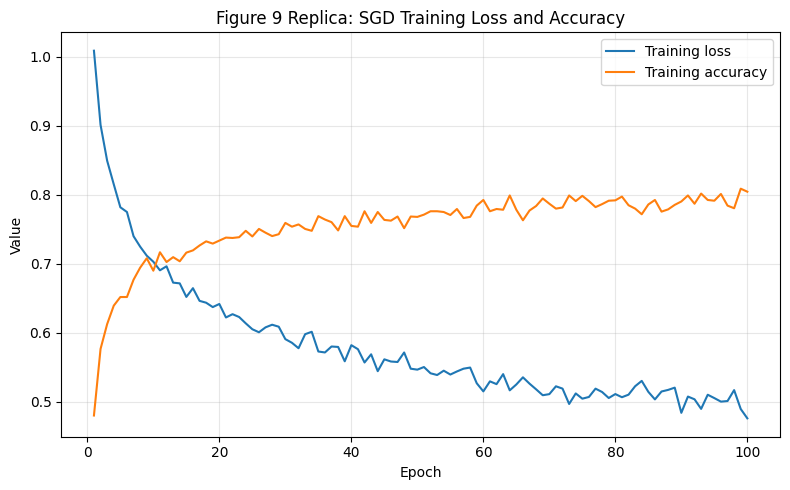

In [13]:
# ============================================================
# Block 10: Figure 9 replica - SGD loss and accuracy trajectory
# ============================================================

if "SGD" in trained_runs:
    sgd_history = trained_runs["SGD"]["history"]
    display(sgd_history.tail())
    sgd_history.to_csv("figure9_sgd_training_history.csv", index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(sgd_history["epoch"], sgd_history["train_loss"], label="Training loss")
    plt.plot(sgd_history["epoch"], sgd_history["train_accuracy"], label="Training accuracy")
    plt.title("Figure 9 Replica: SGD Training Loss and Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("figure9_sgd_loss_accuracy_trajectory.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("SGD was not trained, so Figure 9 cannot be generated.")

## Block 11: Five-fold cross-validation

This block mirrors the paper's statement that five-fold CV was implemented. In leakage-safe mode, the fold split is done on original images, training images are augmented, and validation images remain untouched. In paper-described mode, folds are performed over augmented image rows.

In [14]:
# ============================================================
# Block 11: Five-fold cross-validation
# ============================================================

RUN_CROSS_VALIDATION = True
CV_EPOCHS = NUM_EPOCHS  # lower this for a faster test run, e.g., 5 or 10

cv_rows = []

if RUN_CROSS_VALIDATION:
    if SPLIT_MODE == "leakage_safe":
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        X_idx = np.arange(len(records_df))
        y = records_df["label"].to_numpy()

        for optimizer_name in OPTIMIZERS_TO_TEST:
            for fold, (train_idx, val_idx) in enumerate(skf.split(X_idx, y), start=1):
                print("\n" + "=" * 70)
                print(f"CV optimizer={optimizer_name}, fold={fold}/5")
                print("=" * 70)

                fold_train_df = records_df.iloc[train_idx].reset_index(drop=True)
                fold_val_df = records_df.iloc[val_idx].reset_index(drop=True)
                fold_train_dataset = SixAugmentedImageDataset(fold_train_df)
                fold_val_dataset = OriginalImageDataset(fold_val_df)
                fold_train_loader = make_loader(fold_train_dataset, shuffle=True)
                fold_val_loader = make_loader(fold_val_dataset, shuffle=False)

                model = build_resnet50_transfer_model(num_classes=len(CLASS_NAMES), freeze_backbone=True)
                history_df = train_one_model(model, fold_train_loader, optimizer_name, num_epochs=CV_EPOCHS)
                y_true, y_pred, y_prob, inf_total_sec, inf_per_sample_sec = predict_model(model, fold_val_loader)
                metrics, cm = paper_style_metrics(y_true, y_pred, inf_total_sec, inf_per_sample_sec)
                cv_rows.append({"optimizer": optimizer_name, "fold": fold, **metrics})

                del model
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    elif SPLIT_MODE == "paper_described":
        full_aug_dataset = SixAugmentedImageDataset(records_df)
        y_aug = np.repeat(records_df["label"].to_numpy(), len(AUGMENTATION_NAMES))
        aug_indices = np.arange(len(full_aug_dataset))
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

        for optimizer_name in OPTIMIZERS_TO_TEST:
            for fold, (train_idx, val_idx) in enumerate(skf.split(aug_indices, y_aug), start=1):
                print("\n" + "=" * 70)
                print(f"CV optimizer={optimizer_name}, fold={fold}/5")
                print("=" * 70)

                fold_train_dataset = SixAugmentedImageDataset(records_df, augmented_indices=aug_indices[train_idx])
                fold_val_dataset = SixAugmentedImageDataset(records_df, augmented_indices=aug_indices[val_idx])
                fold_train_loader = make_loader(fold_train_dataset, shuffle=True)
                fold_val_loader = make_loader(fold_val_dataset, shuffle=False)

                model = build_resnet50_transfer_model(num_classes=len(CLASS_NAMES), freeze_backbone=True)
                history_df = train_one_model(model, fold_train_loader, optimizer_name, num_epochs=CV_EPOCHS)
                y_true, y_pred, y_prob, inf_total_sec, inf_per_sample_sec = predict_model(model, fold_val_loader)
                metrics, cm = paper_style_metrics(y_true, y_pred, inf_total_sec, inf_per_sample_sec)
                cv_rows.append({"optimizer": optimizer_name, "fold": fold, **metrics})

                del model
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

cv_results_df = pd.DataFrame(cv_rows)
if len(cv_results_df):
    display(cv_results_df)
    cv_results_df.to_csv("five_fold_cv_raw_results.csv", index=False)

    cv_summary_df = cv_results_df.groupby("optimizer").agg(
        ACC_mean=("ACC", "mean"), ACC_std=("ACC", "std"),
        PRC_mean=("PRC", "mean"), PRC_std=("PRC", "std"),
        RCL_mean=("RCL", "mean"), RCL_std=("RCL", "std"),
        F1S_mean=("F1S", "mean"), F1S_std=("F1S", "std"),
        INF_per_sample_mean=("INF_per_sample_sec", "mean"),
        INF_per_sample_std=("INF_per_sample_sec", "std"),
    ).reset_index()
    print("5-fold CV summary:")
    display(cv_summary_df)
    cv_summary_df.to_csv("five_fold_cv_summary.csv", index=False)
else:
    print("Cross-validation skipped.")


CV optimizer=SGD, fold=1/5


SGD epoch 1/100:   0%|          | 0/408 [00:00<?, ?it/s]

SGD epoch 2/100:   0%|          | 0/408 [00:00<?, ?it/s]

SGD epoch 3/100:   0%|          | 0/408 [00:00<?, ?it/s]

SGD epoch 4/100:   0%|          | 0/408 [00:00<?, ?it/s]

...

RMSProp epoch 99/100:   0%|          | 0/408 [00:00<?, ?it/s]

RMSProp epoch 100/100:   0%|          | 0/408 [00:00<?, ?it/s]

,optimizer,fold,NCC,NIC,ACC,PRC,RCL,F1S,PRC_macro,RCL_macro,F1S_macro,INF_total_sec,INF_per_sample_sec
0,SGD,1,307,101,0.752451,0.756025,0.752451,0.744752,0.755692,0.758628,0.747936,4.223314,0.010351
1,SGD,2,271,137,0.664216,0.658122,0.664216,0.652339,0.659278,0.671296,0.656707,4.207391,0.010312
2,SGD,3,279,129,0.683824,0.678854,0.683824,0.679189,0.680796,0.688763,0.682683,4.334456,0.010624
3,SGD,4,277,131,0.678922,0.674338,0.678922,0.667395,0.675871,0.686237,0.672035,4.320110,0.010589
4,SGD,5,279,129,0.683824,0.681978,0.683824,0.680863,0.683977,0.688342,0.684147,4.179728,0.010244
5,Adam,1,290,118,0.710784,0.706319,0.710784,0.705607,0.708531,0.716330,0.709542,4.207749,0.010313
6,Adam,2,279,129,0.683824,0.676966,0.683824,0.671921,0.678169,0.690867,0.676269,4.225735,0.010357
7,Adam,3,280,128,0.686275,0.681155,0.686275,0.679582,0.682924,0.692130,0.683497,4.271175,0.010469
8,Adam,4,267,141,0.654412,0.643353,0.654412,0.642116,0.645532,0.661616,0.646970,4.256073,0.010432
9,Adam,5,282,126,0.691176,0.687608,0.691176,0.680959,0.688539,0.698022,0.685087,4.206527,0.010310


5-fold CV summary:


,optimizer,ACC_mean,ACC_std,PRC_mean,PRC_std,RCL_mean,RCL_std,F1S_mean,F1S_std,INF_per_sample_mean,INF_per_sample_std
0,Adam,0.685294,0.020256,0.679080,0.022912,0.685294,0.020256,0.676037,0.022797,0.010376,0.000071
1,RMSProp,0.689706,0.015365,0.687166,0.018247,0.689706,0.015365,0.680084,0.017429,0.010361,0.000101
2,SGD,0.692647,0.034384,0.689863,0.038109,0.692647,0.034384,0.684908,0.035347,0.010424,0.000171


Correlation matrix across optimizer-level numerical metrics:


,NCC,NIC,ACC,PRC,RCL,F1S,PRC_macro,RCL_macro,F1S_macro,INF_total_sec,INF_per_sample_sec
NCC,1.000000,-1.000000,1.000000,0.948067,1.000000,0.965220,0.932945,0.990072,0.968055,0.491637,0.491637
NIC,-1.000000,1.000000,-1.000000,-0.948067,-1.000000,-0.965220,-0.932945,-0.990072,-0.968055,-0.491637,-0.491637
ACC,1.000000,-1.000000,1.000000,0.948067,1.000000,0.965220,0.932945,0.990072,0.968055,0.491637,0.491637
PRC,0.948067,-0.948067,0.948067,1.000000,0.948067,0.998249,0.999006,0.893946,0.997534,0.189129,0.189129
RCL,1.000000,-1.000000,1.000000,0.948067,1.000000,0.965220,0.932945,0.990072,0.968055,0.491637,0.491637
F1S,0.965220,-0.965220,0.965220,0.998249,0.965220,1.000000,0.994620,0.918888,0.999939,0.246875,0.246875
PRC_macro,0.932945,-0.932945,0.932945,0.999006,0.932945,0.994620,1.000000,0.873078,0.993413,0.145165,0.145165
RCL_macro,0.990072,-0.990072,0.990072,0.893946,0.990072,0.918888,0.873078,1.000000,0.923199,0.609157,0.609157
F1S_macro,0.968055,-0.968055,0.968055,0.997534,0.968055,0.999939,0.993413,0.923199,1.000000,0.257587,0.257587
INF_total_sec,0.491637,-0.491637,0.491637,0.189129,0.491637,0.246875,0.145165,0.609157,0.257587,1.000000,1.000000


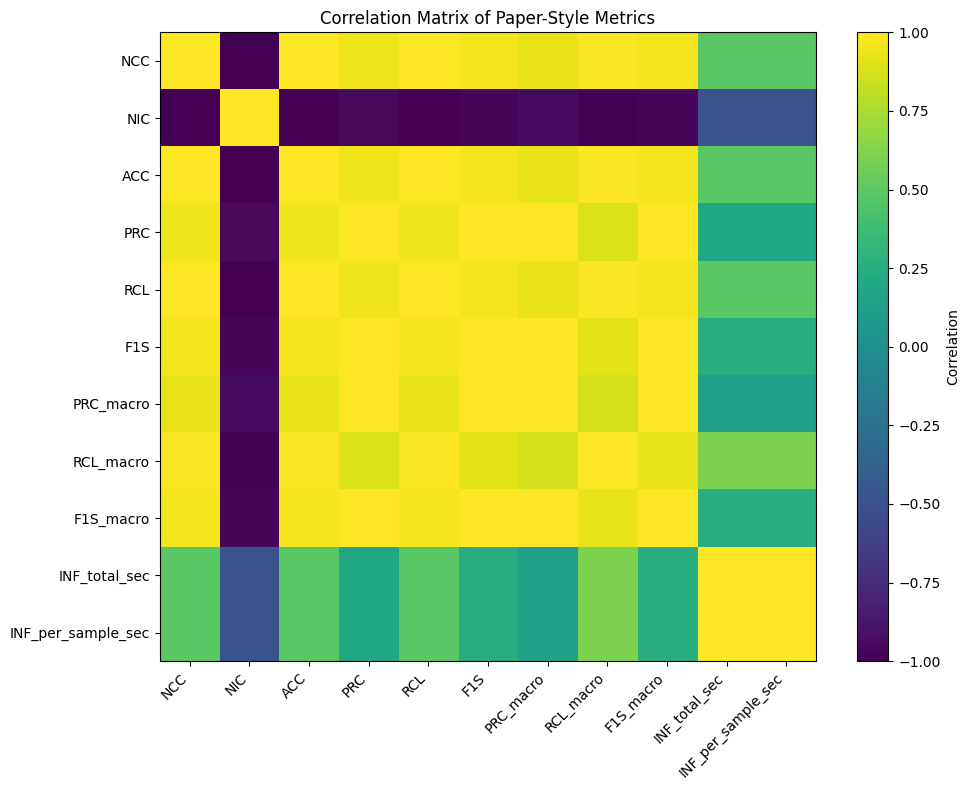

In [15]:
# ============================================================
# Block 12: Correlation matrix of numerical model metrics
# ============================================================

numeric_metric_cols = [
    "NCC", "NIC", "ACC", "PRC", "RCL", "F1S",
    "PRC_macro", "RCL_macro", "F1S_macro",
    "INF_total_sec", "INF_per_sample_sec",
]

corr_df = results_df[numeric_metric_cols].corr(numeric_only=True)
print("Correlation matrix across optimizer-level numerical metrics:")
display(corr_df)
corr_df.to_csv("optimizer_metrics_correlation_matrix.csv")

plt.figure(figsize=(10, 8))
plt.imshow(corr_df, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_df.columns)), corr_df.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_df.index)), corr_df.index)
plt.title("Correlation Matrix of Paper-Style Metrics")
plt.tight_layout()
plt.savefig("optimizer_metrics_correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

In [16]:
# ============================================================
# Block 13: Save the best model and final report artifacts
# ============================================================

best_optimizer = results_df.iloc[0]["optimizer"]
best_run = trained_runs[best_optimizer]

model_path = f"best_resnet50_kefra_{best_optimizer}.pt"
torch.save({
    "model_state_dict": best_run["model"].state_dict(),
    "class_names": CLASS_NAMES,
    "optimizer": best_optimizer,
    "image_size": IMAGE_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "split_mode": SPLIT_MODE,
    "metrics": best_run["metrics"],
}, model_path)

summary = {
    "paper": "Abu Al-Haija & Alsulami (2022), Electronics 11(20), 3376",
    "dataset_root": str(DATA_ROOT),
    "split_mode": SPLIT_MODE,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "epochs": NUM_EPOCHS,
    "optimizers": OPTIMIZERS_TO_TEST,
    "best_optimizer": best_optimizer,
    "best_metrics": best_run["metrics"],
}
with open("experiment_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Best optimizer:", best_optimizer)
print("Saved model:", model_path)
print("Saved summary: experiment_summary.json")
print("Saved figures/tables in the current notebook working directory.")

Best optimizer: RMSProp
Saved model: best_resnet50_kefra_RMSProp.pt
Saved summary: experiment_summary.json
Saved figures/tables in the current notebook working directory.


## Interpretation checklist

After running the notebook, compare your results with the paper's reported outcomes:

- SGD: 339 correct / 1 incorrect, approximately 99.71%
- Adam: 320 correct / 20 incorrect, approximately 94.12%
- RMSProp: 270 correct / 70 incorrect, approximately 79.41%

If your numbers differ, likely causes include:

1. Different split behavior: leakage-safe split versus paper-described augmentation-before-split.
2. PyTorch versus MATLAB implementation differences.
3. Different random augmentation ranges. The paper does not publish exact min/max values.
4. Different ResNet50 ImageNet weight version.
5. Different GPU and nondeterministic CUDA operations.
6. Dataset folder contents/counts differing from the paper's 340-image dataset.

For a defensible final report, use the leakage-safe results and explicitly say you split by original images before augmentation to avoid augmented-sibling leakage.